In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

# sns.set(context='talk')
%matplotlib widget
# %matplotlib inline

### load

In [2]:
pca_df = pd.read_csv('../../results/pca_df.csv')
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.047619,0,0,0.0,-0.343129,-0.006083,0.023421
1,0.25,b=0.25,0.047619,1,0,0.0,-0.343129,-0.006083,0.023421
2,0.25,b=0.25,0.095238,2,1,0.0,-0.328170,-0.001651,0.013417
3,0.25,b=0.25,0.095238,3,1,0.0,-0.328171,-0.001652,0.013417
4,0.25,b=0.25,0.142857,4,2,0.0,-0.306723,0.002879,0.007066


In [3]:
beh_df      = pd.read_csv('../../results/beh_df.csv')
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned,stim_rank,resp_rank
0,0.25,b=0.25,0.047619,0,0,0.0,0.169804,0.0,0,-0.202381,-0.080196,1.5,1.5
1,0.25,b=0.25,0.047619,1,0,0.0,0.169804,0.0,0,-0.202381,-0.080196,1.5,1.5
2,0.25,b=0.25,0.095238,2,1,0.0,0.182941,0.0,0,-0.154762,-0.067059,3.5,3.5
3,0.25,b=0.25,0.095238,3,1,0.0,0.182941,0.0,0,-0.154762,-0.067059,3.5,3.5
4,0.25,b=0.25,0.142857,4,2,0.0,0.196852,0.0,0,-0.107143,-0.053148,5.5,5.5


In [4]:
hidden_stack = np.load('../../results/hidden_stack.npy')
print(f'hidden_stack shape: {hidden_stack.shape}')  # (n_nets, 60, 10)
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]
print(f'hidden_mean shape: {hidden_mean.shape}')

boundaries = tuple(sorted(pca_df['boundary'].unique()))
print(f'boundaries: {boundaries}')

hidden_stack shape: (30, 60, 10)
hidden_mean shape: (60, 10)
boundaries: (np.float64(0.25), np.float64(0.5), np.float64(0.75))


## Single-Unit

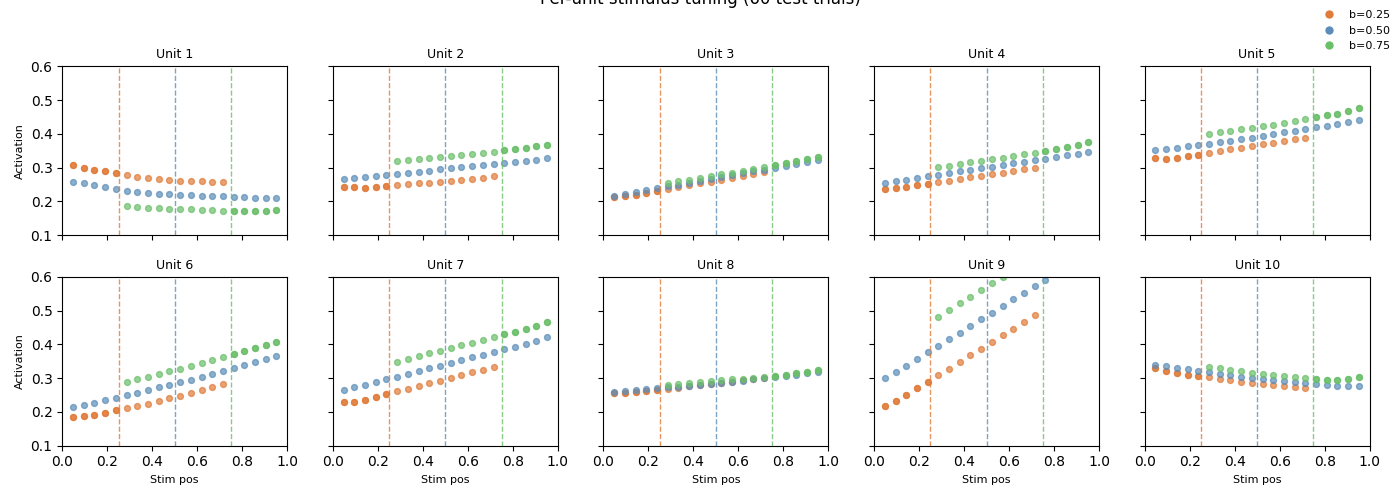

In [5]:
# build tuning_df
n_units = hidden_mean.shape[1]
cond_colors = {0.25: '#e07b39', 0.50: '#5b8db8', 0.75: '#6abf69'}

tuning_df = pca_df[['boundary', 'stim']].copy().reset_index(drop=True)
for i in range(n_units):
    tuning_df[f'unit_{i}'] = hidden_mean[:, i]

# 5×2 per-unit grid
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    for bound in boundaries:
        cond_df = tuning_df[tuning_df['boundary'] == bound].sort_values('stim')
        ax.scatter(cond_df['stim'], cond_df[f'unit_{i}'],
                   color=cond_colors[bound], s=18, alpha=0.7)
        ax.axvline(bound, color=cond_colors[bound], linestyle='--', linewidth=1, alpha=0.8)
    ax.set_title(f'Unit {i+1}', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.1, 0.6)
    if i % 5 == 0:
        ax.set_ylabel('Activation', fontsize=8)
    if i >= 5:
        ax.set_xlabel('Stim pos', fontsize=8)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cond_colors[b],
               markersize=7, label=f'b={b:.2f}')
    for b in boundaries
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=8, frameon=False,
           bbox_to_anchor=(1.0, 1.0))
plt.suptitle('Per-unit stimulus tuning (60 test trials)', y=1.02)
plt.tight_layout()
plt.show()

### PCA on encoding

In [6]:
sns.set(context='paper')
sns.set_style('white')
from matplotlib.lines import Line2D

# average hidden activations across networks for each of the 60 trials
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

pca_df = pca_df.copy()

# raw PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# shared norm over global stim range
shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

# marker per condition
cond_markers = {0.25: 's', 0.50: 'o', 0.75: '^'}

# stim range common across all conditions
stim_lo, stim_hi = 0.25, 0.75

# PC-centroid-subtracted
pca3 = PCA(n_components=3)
pcs3 = pca3.fit_transform(hidden_mean)
pcs3_centered = pcs3.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    pcs3_centered[idx] = pcs3[idx] - pcs3[idx].mean(axis=0)
pca_df['PC1_pcc'] = pcs3_centered[:, 0]
pca_df['PC2_pcc'] = pcs3_centered[:, 1]
pca_df['PC3_pcc'] = pcs3_centered[:, 2]

# hidden-centroid-subtracted, then PCA
hidden_centered = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    hidden_centered[idx] = hidden_mean[idx] - hidden_mean[idx].mean(axis=0)
pca2 = PCA(n_components=3)
pcs2 = pca2.fit_transform(hidden_centered)
pca_df['PC1_c'] = pcs2[:, 0]
pca_df['PC2_c'] = pcs2[:, 1]
pca_df['PC3_c'] = pcs2[:, 2]

# view angle
view_elev = 24
view_azim = -65

print('PCA setup done.')

PCA setup done.


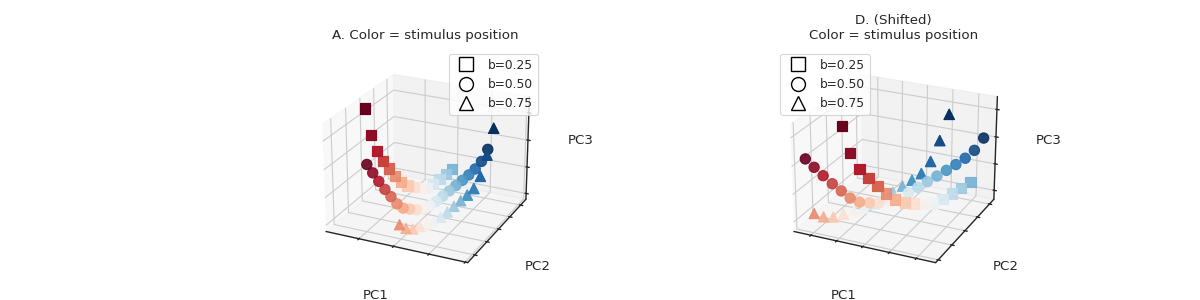

In [18]:
shared_cmap = plt.cm.RdBu

# legend: swatch at the boundary value on the global stim scale
legend_handles_shared = [
    Line2D([0], [0], marker=cond_markers[bound], color='w',
           markerfacecolor='white', markeredgecolor='black', markersize=10,
           label=f'b={bound:.2f}')
    for bound in boundaries
]

def get_cond_df(bound, sort_col='stim'):
    # return pca_df[(pca_df['boundary'] == bound) & pca_df['stim'].between(stim_lo, stim_hi)].sort_values(sort_col)
    return pca_df[pca_df['boundary'] == bound].sort_values(sort_col)

# plot raw PCA, shared RdBu_r
fig = plt.figure(figsize=(12, 3))

# Plot 1: Raw PCA
ax = fig.add_subplot(121, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
ax.set_title('A. Color = stimulus position')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

# Plot 2: PC-centroid-subtracted
ax = fig.add_subplot(122, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap(shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# ax.set_title('PC-centroid-subtracted\nColor = stimulus position')
ax.set_title('D. (Shifted)\nColor = stimulus position')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

plt.tight_layout()
plt.show()

### Boundary-relative coding

In [8]:
# === stim_aligned (relative to boundary) coloring with diverging colormap ===

# merge stim_aligned from beh_df into pca_df
pca_df['stim_aligned'] = beh_df.loc[pca_df.index, 'stim_aligned'].values

# symmetric norm for stim_aligned (diverging colormap: red=below boundary, blue=above)
stim_aligned_abs_max = max(abs(pca_df['stim_aligned'].min()), abs(pca_df['stim_aligned'].max()))
shared_norm_aligned = Normalize(vmin=-stim_aligned_abs_max, vmax=stim_aligned_abs_max)
shared_cmap_aligned = plt.cm.RdBu

print(f'stim_aligned range: [{pca_df["stim_aligned"].min():.4f}, {pca_df["stim_aligned"].max():.4f}]')

stim_aligned range: [-0.4643, 0.4643]


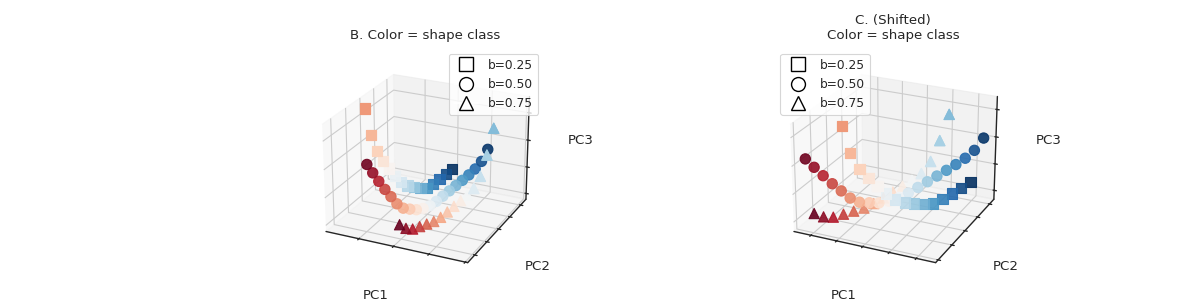

In [19]:
# plot raw PCA, stim_aligned colored (diverging RdBu_r)
fig = plt.figure(figsize=(12, 3))

# Plot 1: Raw PCA
ax = fig.add_subplot(121, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap_aligned(shared_norm_aligned(cond_df['stim_aligned'].values))
    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
ax.set_title('B. Color = shape class')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

# Plot 2: PC-centroid-subtracted
ax = fig.add_subplot(122, projection='3d')
for bound in boundaries:
    cond_df = get_cond_df(bound)
    colors = shared_cmap_aligned(shared_norm_aligned(cond_df['stim_aligned'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# ax.set_title('Centroid-subtracted\n(stim rel. to boundary)')
ax.set_title('C. (Shifted)\nColor = shape class')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles_shared, loc='best')

plt.tight_layout()
plt.show()

### Analyzing relative coding

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Cross-context generalization test
# Does stim from context A predict neural activity in contexts B & C?
# vs. Does stim_aligned from context A predict activity in B & C?

results = []

for train_bound in boundaries:
    train_idx = pca_df[pca_df['boundary'] == train_bound].index
    test_bounds = [b for b in boundaries if b != train_bound]
    
    print(f"\n{'='*60}")
    print(f"Train on boundary = {train_bound:.2f}")
    print(f"{'='*60}")
    
    # ===== ABSOLUTE CODING (stim) =====
    print(f"\n--- ABSOLUTE CODING (stim) ---")
    X_train_abs = pca_df.loc[train_idx, 'stim'].values.reshape(-1, 1)
    y_train = hidden_mean[train_idx]
    
    model_abs = LinearRegression()
    model_abs.fit(X_train_abs, y_train)
    train_r2_abs = r2_score(y_train, model_abs.predict(X_train_abs))
    print(f"Train R² (on b={train_bound:.2f}): {train_r2_abs:.4f}")
    
    for test_bound in test_bounds:
        test_idx = pca_df[pca_df['boundary'] == test_bound].index
        X_test_abs = pca_df.loc[test_idx, 'stim'].values.reshape(-1, 1)
        y_test = hidden_mean[test_idx]
        test_r2_abs = r2_score(y_test, model_abs.predict(X_test_abs))
        print(f"  Test R² (on b={test_bound:.2f}): {test_r2_abs:.4f}")
        results.append({
            'train_bound': train_bound, 'test_bound': test_bound,
            'coding': 'absolute', 'r2': test_r2_abs
        })
    
    # ===== RELATIVE CODING (stim_aligned) =====
    print(f"\n--- RELATIVE CODING (stim_aligned) ---")
    X_train_rel = pca_df.loc[train_idx, 'stim_aligned'].values.reshape(-1, 1)
    
    model_rel = LinearRegression()
    model_rel.fit(X_train_rel, y_train)
    train_r2_rel = r2_score(y_train, model_rel.predict(X_train_rel))
    print(f"Train R² (on b={train_bound:.2f}): {train_r2_rel:.4f}")
    
    for test_bound in test_bounds:
        test_idx = pca_df[pca_df['boundary'] == test_bound].index
        X_test_rel = pca_df.loc[test_idx, 'stim_aligned'].values.reshape(-1, 1)
        y_test = hidden_mean[test_idx]
        test_r2_rel = r2_score(y_test, model_rel.predict(X_test_rel))
        print(f"  Test R² (on b={test_bound:.2f}): {test_r2_rel:.4f}")
        results.append({
            'train_bound': train_bound, 'test_bound': test_bound,
            'coding': 'relative', 'r2': test_r2_rel
        })

# Summary table
results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print("SUMMARY: Cross-context generalization")
print(f"{'='*60}")
for train_bound in boundaries:
    subset = results_df[results_df['train_bound'] == train_bound]
    print(f"\nTrained on b={train_bound:.2f}:")
    for test_bound in boundaries:
        if test_bound == train_bound:
            continue
        abs_r2 = subset[(subset['test_bound'] == test_bound) & (subset['coding'] == 'absolute')]['r2'].values[0]
        rel_r2 = subset[(subset['test_bound'] == test_bound) & (subset['coding'] == 'relative')]['r2'].values[0]
        winner = "RELATIVE ✓" if rel_r2 > abs_r2 else "ABSOLUTE ✓"
        print(f"  → Test on b={test_bound:.2f}: Abs={abs_r2:.4f} vs Rel={rel_r2:.4f}  [{winner}]")



Train on boundary = 0.25

--- ABSOLUTE CODING (stim) ---
Train R² (on b=0.25): 0.9838
  Test R² (on b=0.50): -0.6585
  Test R² (on b=0.75): -32.9374

--- RELATIVE CODING (stim_aligned) ---
Train R² (on b=0.25): 0.9838
  Test R² (on b=0.50): -3.1881
  Test R² (on b=0.75): -77.3745

Train on boundary = 0.50

--- ABSOLUTE CODING (stim) ---
Train R² (on b=0.50): 0.9852
  Test R² (on b=0.25): -1.4990
  Test R² (on b=0.75): -8.6627

--- RELATIVE CODING (stim_aligned) ---
Train R² (on b=0.50): 0.9852
  Test R² (on b=0.25): -5.8081
  Test R² (on b=0.75): -16.9541

Train on boundary = 0.75

--- ABSOLUTE CODING (stim) ---
Train R² (on b=0.75): 0.9591
  Test R² (on b=0.25): -9.6927
  Test R² (on b=0.50): -0.9287

--- RELATIVE CODING (stim_aligned) ---
Train R² (on b=0.75): 0.9591
  Test R² (on b=0.25): -27.2826
  Test R² (on b=0.50): -3.1601

SUMMARY: Cross-context generalization

Trained on b=0.25:
  → Test on b=0.50: Abs=-0.6585 vs Rel=-3.1881  [ABSOLUTE ✓]
  → Test on b=0.75: Abs=-32.9374 vs 

## Cross-context generalization: Absolute vs Relative coding

In [11]:
# === CONTROL: Test with context-aligned hidden space ===
# Subtract per-boundary mean activation (analogous to PC-centroid-subtraction in high dim)
hidden_aligned = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    hidden_aligned[idx] = hidden_mean[idx] - hidden_mean[idx].mean(axis=0)

print(f"\n{'='*60}")
print("CONTROL: Cross-context generalization on CONTEXT-ALIGNED hidden space")
print(f"{'='*60}")

results_aligned = []

for train_bound in boundaries:
    train_idx = pca_df[pca_df['boundary'] == train_bound].index
    test_bounds = [b for b in boundaries if b != train_bound]
    
    print(f"\n{'='*60}")
    print(f"Train on boundary = {train_bound:.2f}")
    print(f"{'='*60}")
    
    # ===== ABSOLUTE CODING (stim) on aligned hidden space =====
    print(f"\n--- ABSOLUTE CODING (stim) ---")
    X_train_abs = pca_df.loc[train_idx, 'stim'].values.reshape(-1, 1)
    y_train_aligned = hidden_aligned[train_idx]
    
    model_abs_aligned = LinearRegression()
    model_abs_aligned.fit(X_train_abs, y_train_aligned)
    train_r2_abs_aligned = r2_score(y_train_aligned, model_abs_aligned.predict(X_train_abs))
    print(f"Train R² (on b={train_bound:.2f}): {train_r2_abs_aligned:.4f}")
    
    for test_bound in test_bounds:
        test_idx = pca_df[pca_df['boundary'] == test_bound].index
        X_test_abs = pca_df.loc[test_idx, 'stim'].values.reshape(-1, 1)
        y_test_aligned = hidden_aligned[test_idx]
        test_r2_abs_aligned = r2_score(y_test_aligned, model_abs_aligned.predict(X_test_abs))
        print(f"  Test R² (on b={test_bound:.2f}): {test_r2_abs_aligned:.4f}")
        results_aligned.append({
            'train_bound': train_bound, 'test_bound': test_bound,
            'coding': 'absolute', 'r2': test_r2_abs_aligned
        })
    
    # ===== RELATIVE CODING (stim_aligned) on aligned hidden space =====
    print(f"\n--- RELATIVE CODING (stim_aligned) ---")
    X_train_rel = pca_df.loc[train_idx, 'stim_aligned'].values.reshape(-1, 1)
    
    model_rel_aligned = LinearRegression()
    model_rel_aligned.fit(X_train_rel, y_train_aligned)
    train_r2_rel_aligned = r2_score(y_train_aligned, model_rel_aligned.predict(X_train_rel))
    print(f"Train R² (on b={train_bound:.2f}): {train_r2_rel_aligned:.4f}")
    
    for test_bound in test_bounds:
        test_idx = pca_df[pca_df['boundary'] == test_bound].index
        X_test_rel = pca_df.loc[test_idx, 'stim_aligned'].values.reshape(-1, 1)
        y_test_aligned = hidden_aligned[test_idx]
        test_r2_rel_aligned = r2_score(y_test_aligned, model_rel_aligned.predict(X_test_rel))
        print(f"  Test R² (on b={test_bound:.2f}): {test_r2_rel_aligned:.4f}")
        results_aligned.append({
            'train_bound': train_bound, 'test_bound': test_bound,
            'coding': 'relative', 'r2': test_r2_rel_aligned
        })

# Summary
results_aligned_df = pd.DataFrame(results_aligned)
print(f"\n{'='*60}")
print("SUMMARY: Cross-context generalization (context-aligned hidden space)")
print(f"{'='*60}")
for train_bound in boundaries:
    subset = results_aligned_df[results_aligned_df['train_bound'] == train_bound]
    print(f"\nTrained on b={train_bound:.2f}:")
    for test_bound in boundaries:
        if test_bound == train_bound:
            continue
        abs_r2 = subset[(subset['test_bound'] == test_bound) & (subset['coding'] == 'absolute')]['r2'].values[0]
        rel_r2 = subset[(subset['test_bound'] == test_bound) & (subset['coding'] == 'relative')]['r2'].values[0]
        winner = "RELATIVE ✓" if rel_r2 > abs_r2 else "ABSOLUTE ✓"
        print(f"  → Test on b={test_bound:.2f}: Abs={abs_r2:.4f} vs Rel={rel_r2:.4f}  [{winner}]")


CONTROL: Cross-context generalization on CONTEXT-ALIGNED hidden space

Train on boundary = 0.25

--- ABSOLUTE CODING (stim) ---
Train R² (on b=0.25): 0.9838
  Test R² (on b=0.50): 0.4895
  Test R² (on b=0.75): -5.9868

--- RELATIVE CODING (stim_aligned) ---
Train R² (on b=0.25): 0.9838
  Test R² (on b=0.50): 0.8699
  Test R² (on b=0.75): -0.7664

Train on boundary = 0.50

--- ABSOLUTE CODING (stim) ---
Train R² (on b=0.50): 0.9852
  Test R² (on b=0.25): 0.1938
  Test R² (on b=0.75): -0.2594

--- RELATIVE CODING (stim_aligned) ---
Train R² (on b=0.50): 0.9852
  Test R² (on b=0.25): 0.8303
  Test R² (on b=0.75): 0.6021

Train on boundary = 0.75

--- ABSOLUTE CODING (stim) ---
Train R² (on b=0.75): 0.9591
  Test R² (on b=0.25): -2.1943
  Test R² (on b=0.50): 0.5496

--- RELATIVE CODING (stim_aligned) ---
Train R² (on b=0.75): 0.9591
  Test R² (on b=0.25): 0.3919
  Test R² (on b=0.50): 0.8795

SUMMARY: Cross-context generalization (context-aligned hidden space)

Trained on b=0.25:
  → Tes

## Class (boundary-side) decoding

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ============ CLASS DECODING: Raw hidden space ============
print(f"\n{'='*60}")
print("CLASS DECODING: Cross-context generalization (RAW hidden space)")
print(f"{'='*60}")

class_results = []

for train_bound in boundaries:
    train_idx = pca_df[pca_df['boundary'] == train_bound].index
    test_bounds = [b for b in boundaries if b != train_bound]
    
    print(f"\nTrained on b={train_bound:.2f}:")
    
    # Extract labels and hidden activations
    y_train_class = pca_df.loc[train_idx, 'class'].values
    X_train_hidden = hidden_mean[train_idx]
    
    # Train logistic classifier
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_hidden, y_train_class)
    train_acc = accuracy_score(y_train_class, clf.predict(X_train_hidden))
    print(f"  Train accuracy: {train_acc:.4f}")
    
    for test_bound in test_bounds:
        test_idx = pca_df[pca_df['boundary'] == test_bound].index
        y_test_class = pca_df.loc[test_idx, 'class'].values
        X_test_hidden = hidden_mean[test_idx]
        
        test_acc = accuracy_score(y_test_class, clf.predict(X_test_hidden))
        test_auc = roc_auc_score(y_test_class, clf.predict_proba(X_test_hidden)[:, 1])
        print(f"  → Test on b={test_bound:.2f}: Acc={test_acc:.4f}  AUC={test_auc:.4f}")
        
        class_results.append({
            'train_bound': train_bound, 'test_bound': test_bound,
            'space': 'raw', 'accuracy': test_acc, 'auc': test_auc
        })

# ============ CLASS DECODING: Context-aligned hidden space ============
print(f"\n{'='*60}")
print("CLASS DECODING: Cross-context generalization (CONTEXT-ALIGNED hidden space)")
print(f"{'='*60}")

for train_bound in boundaries:
    train_idx = pca_df[pca_df['boundary'] == train_bound].index
    test_bounds = [b for b in boundaries if b != train_bound]
    
    print(f"\nTrained on b={train_bound:.2f}:")
    
    y_train_class = pca_df.loc[train_idx, 'class'].values
    X_train_hidden_aligned = hidden_aligned[train_idx]
    
    clf_aligned = LogisticRegression(max_iter=1000)
    clf_aligned.fit(X_train_hidden_aligned, y_train_class)
    train_acc_aligned = accuracy_score(y_train_class, clf_aligned.predict(X_train_hidden_aligned))
    print(f"  Train accuracy: {train_acc_aligned:.4f}")
    
    for test_bound in test_bounds:
        test_idx = pca_df[pca_df['boundary'] == test_bound].index
        y_test_class = pca_df.loc[test_idx, 'class'].values
        X_test_hidden_aligned = hidden_aligned[test_idx]
        
        test_acc_aligned = accuracy_score(y_test_class, clf_aligned.predict(X_test_hidden_aligned))
        test_auc_aligned = roc_auc_score(y_test_class, clf_aligned.predict_proba(X_test_hidden_aligned)[:, 1])
        print(f"  → Test on b={test_bound:.2f}: Acc={test_acc_aligned:.4f}  AUC={test_auc_aligned:.4f}")
        
        class_results.append({
            'train_bound': train_bound, 'test_bound': test_bound,
            'space': 'aligned', 'accuracy': test_acc_aligned, 'auc': test_auc_aligned
        })


CLASS DECODING: Cross-context generalization (RAW hidden space)

Trained on b=0.25:
  Train accuracy: 0.9500
  → Test on b=0.50: Acc=0.6000  AUC=1.0000
  → Test on b=0.75: Acc=0.5000  AUC=1.0000

Trained on b=0.50:
  Train accuracy: 1.0000
  → Test on b=0.25: Acc=0.5500  AUC=1.0000
  → Test on b=0.75: Acc=0.5000  AUC=1.0000

Trained on b=0.75:
  Train accuracy: 0.9500
  → Test on b=0.25: Acc=0.5000  AUC=1.0000
  → Test on b=0.50: Acc=0.6000  AUC=1.0000

CLASS DECODING: Cross-context generalization (CONTEXT-ALIGNED hidden space)

Trained on b=0.25:
  Train accuracy: 0.9500
  → Test on b=0.50: Acc=1.0000  AUC=1.0000
  → Test on b=0.75: Acc=0.9500  AUC=1.0000

Trained on b=0.50:
  Train accuracy: 1.0000
  → Test on b=0.25: Acc=0.9500  AUC=1.0000
  → Test on b=0.75: Acc=0.9500  AUC=1.0000

Trained on b=0.75:
  Train accuracy: 0.9500
  → Test on b=0.25: Acc=0.9500  AUC=1.0000
  → Test on b=0.50: Acc=1.0000  AUC=1.0000


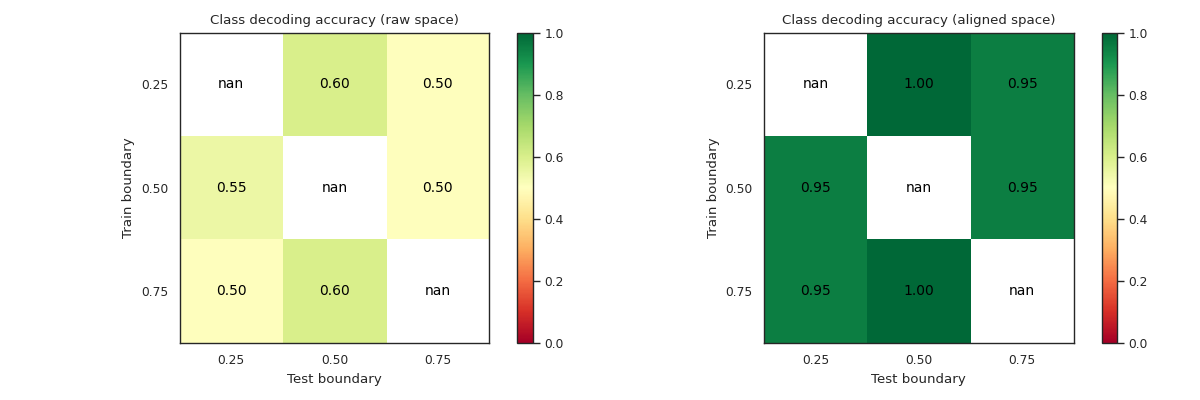

In [13]:
# ============ Visualization ============
class_results_df = pd.DataFrame(class_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, space in enumerate(['raw', 'aligned']):
    ax = axes[idx]
    subset = class_results_df[class_results_df['space'] == space]
    
    # Pivot for heatmap: rows=train_bound, cols=test_bound, values=accuracy
    acc_pivot = subset.pivot_table(
        index='train_bound', columns='test_bound', values='accuracy'
    )
    
    im = ax.imshow(acc_pivot.values, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(acc_pivot.columns)))
    ax.set_yticks(range(len(acc_pivot.index)))
    ax.set_xticklabels([f'{b:.2f}' for b in acc_pivot.columns])
    ax.set_yticklabels([f'{b:.2f}' for b in acc_pivot.index])
    ax.set_xlabel('Test boundary')
    ax.set_ylabel('Train boundary')
    ax.set_title(f'Class decoding accuracy ({space} space)')
    
    # Add text annotations
    for i, train_b in enumerate(acc_pivot.index):
        for j, test_b in enumerate(acc_pivot.columns):
            text = ax.text(j, i, f'{acc_pivot.values[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()